In [62]:
from src.gmm import GMM
from src.dg import DataGenerator
from src.metrics import energy_distance, hellinger_gaussian_diag_gmm, hellinger_normal_gmm

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, logistic, t, gaussian_kde

import torch

from src.test import TorchGaussianMixture
from sklearn.mixture import GaussianMixture

In [63]:
# global parameters
N = 2000
d = 3

## Gaussian mixture with $k=5$

In [64]:
dist = 'gaussian_mixture'

# true parameters of the gaussian mixture
k = 5
mu0 = torch.rand((k, d)) * 2 - 1 # [-1, 1]
sigma0 = torch.rand((k, d)) * 2 # (0, 2)
pi0 = torch.rand(k) + 0.1
pi0 = pi0 / pi0.sum()

dg = DataGenerator(dist, mu=mu0, sigma=sigma0, pi=pi0)
X, M = dg.generate(N, d)
M_full = torch.ones_like(M)

### Old version GM

In [65]:
# GMM settings
cov_type = 'diag' # diag, id, uni_diag, uni_id
n_k = 10
start = 0
step = 1
n_mc = 100
n_samples = 2000

gmm_full = GMM(X, M_full, 'uni_diag')

mu, sigma, pi, kk, q_x1, corr, loglik, aic, bic = gmm_full.iterEM(n_k, start, step, n_mc, n_samples)

choice of k = 9


In [66]:
gmm_ed = [energy_distance(X, gmm_full.sample_gmm(mu, sigma, pi, n_samples)).item() for _ in range(100)]

In [67]:
k = mu.shape[0]

### Sklearn GM

In [68]:
gmm_sk = GaussianMixture(
    n_components=k,
    covariance_type='diag',
    random_state=0,
    init_params='random'
)
gmm_sk.fit(X)

gmm_sk_ed = [energy_distance(X, torch.tensor(gmm_sk.sample(n_samples)[0])) for _ in range(100)]

### KDE

In [69]:
kde = gaussian_kde(X.T)
kde_ed = [energy_distance(X, torch.tensor(kde.resample(n_samples)).T).item() for _ in range(100)]

### New GM

In [70]:
gmmt = TorchGaussianMixture(n_components=k, device='cpu', cov_type='uni_diag', n_init=20)
gmmt.fit(X, M_full)

gmmt_ed = [energy_distance(X, gmmt.sample(n_samples)[0]) for _ in range(100)]

### New GM with missingness

In [71]:
gmmt_miss = TorchGaussianMixture(n_components=k, device='cpu', cov_type='uni_diag', n_init=20)
gmmt_miss.fit(X, M)

gmmt_miss_ed = [energy_distance(X, gmmt_miss.sample(n_samples)[0]) for _ in range(100)]

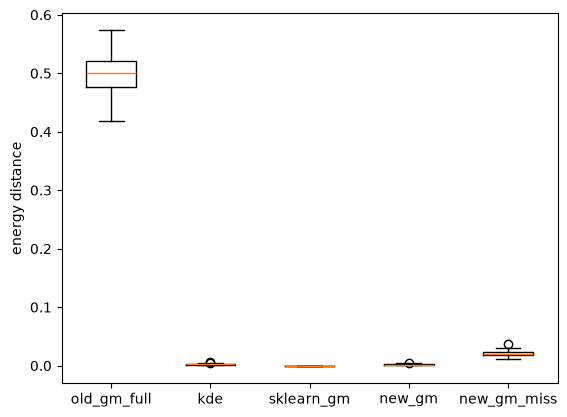

In [72]:
plt.boxplot([gmm_ed, kde_ed, gmm_sk_ed, gmmt_ed, gmmt_miss_ed])
plt.xticks([1, 2, 3, 4, 5], ['old_gm_full', 'kde', 'sklearn_gm', 'new_gm', 'new_gm_miss'])
plt.ylabel('energy distance')
plt.show()

## Normal

$\Sigma = \begin{bmatrix} 1 & 0.7 & 0 \\ 0.7 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}$

In [73]:
# param_vals
dist = 'Normal' # Logistic, Normal, Student t
alpha = 0.7

#df = 3 # for Student t in particular
dg = DataGenerator(dist, alpha)
X, M = dg.generate(N, d)
M_full = torch.ones_like(M)

### Old version GM

In [74]:
# GMM settings
cov_type = 'diag' # diag, id, uni_diag, uni_id
n_k = 10
start = 0
step = 1
n_mc = 100
n_samples = 2000

gmm_full = GMM(X, M_full, 'uni_diag')

mu, sigma, pi, kk, q_x1, corr, loglik, aic, bic = gmm_full.iterEM(n_k, start, step, n_mc, n_samples)

choice of k = 7


In [75]:
gmm_ed = [energy_distance(X, gmm_full.sample_gmm(mu, sigma, pi, n_samples)).item() for _ in range(100)]

In [76]:
k = mu.shape[0]

### Sklearn GM

In [77]:
gmm_sk = GaussianMixture(
    n_components=k,
    covariance_type='diag',
    random_state=0,
    init_params='random'
)
gmm_sk.fit(X)

gmm_sk_ed = [energy_distance(X, torch.tensor(gmm_sk.sample(n_samples)[0])) for _ in range(100)]

### KDE

In [78]:
kde = gaussian_kde(X.T)
kde_ed = [energy_distance(X, torch.tensor(kde.resample(n_samples)).T).item() for _ in range(100)]

### New GM

In [79]:
gmmt = TorchGaussianMixture(n_components=k, device='cpu', cov_type='uni_diag', n_init=20)
gmmt.fit(X, M_full)

gmmt_ed = [energy_distance(X, gmmt.sample(n_samples)[0]) for _ in range(100)]

### New GM with missingness

In [80]:
gmmt_miss = TorchGaussianMixture(n_components=k, device='cpu', cov_type='uni_diag', n_init=20)
gmmt_miss.fit(X, M)

gmmt_miss_ed = [energy_distance(X, gmmt_miss.sample(n_samples)[0]) for _ in range(100)]

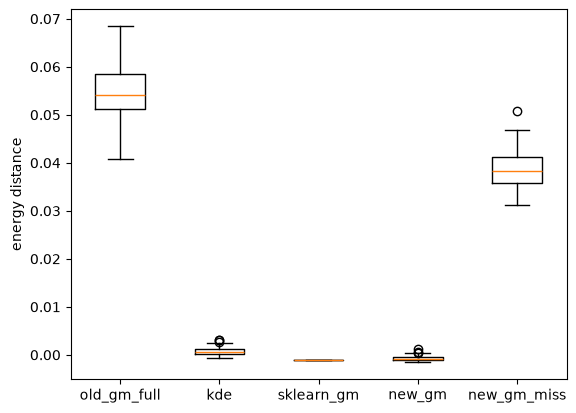

In [81]:
plt.boxplot([gmm_ed, kde_ed, gmm_sk_ed, gmmt_ed, gmmt_miss_ed])
plt.xticks([1, 2, 3, 4, 5], ['old_gm_full', 'kde', 'sklearn_gm', 'new_gm', 'new_gm_miss'])
plt.ylabel('energy distance')
plt.show()